# Tips

### Introduction:

This exercise was created based on the tutorial and documentation from [Seaborn](https://stanford.edu/~mwaskom/software/seaborn/index.html)  
The dataset being used is tips from Seaborn.

### Step 1. Import the necessary libraries:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Tips/tips.csv).

### Step 3. Assign it to a variable called tips

In [8]:
tips = pd.read_csv("https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Tips/tips.csv")

In [9]:
tips

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


### Step 4. Delete the Unnamed 0 column

In [10]:
tips.drop("Unnamed: 0", axis=1, inplace=True)

### Step 5. Plot the total_bill column histogram

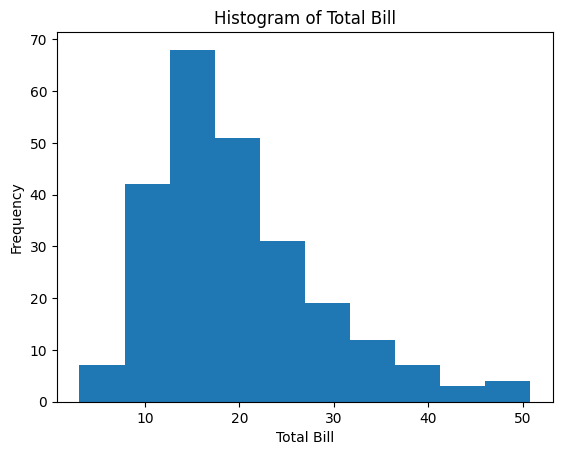

In [11]:
plt.hist(tips['total_bill'])
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill')
plt.show()

### Step 6. Create a scatter plot presenting the relationship between total_bill and tip

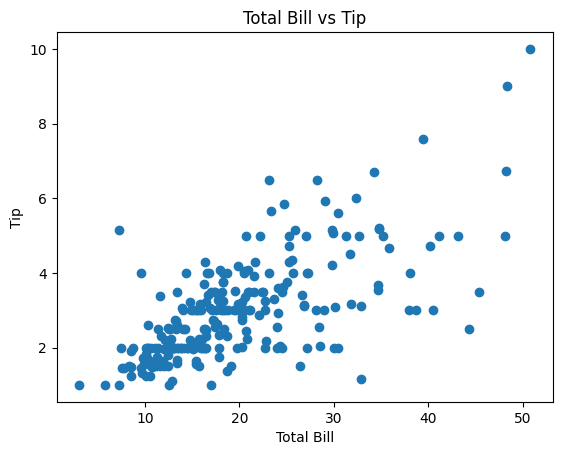

In [12]:
plt.scatter(x=tips['total_bill'], y=tips['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip')
plt.show()

### Step 7.  Create one image with the relationship of total_bill, tip and size.
#### Hint: It is just one function.

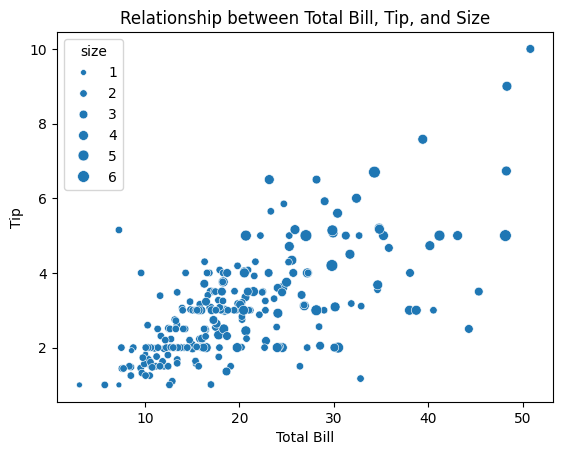

In [13]:
import seaborn as sns
sns.scatterplot(x='total_bill', y='tip', size='size', data=tips)
plt.title('Relationship between Total Bill, Tip, and Size')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

### Step 8. Present the relationship between days and total_bill value

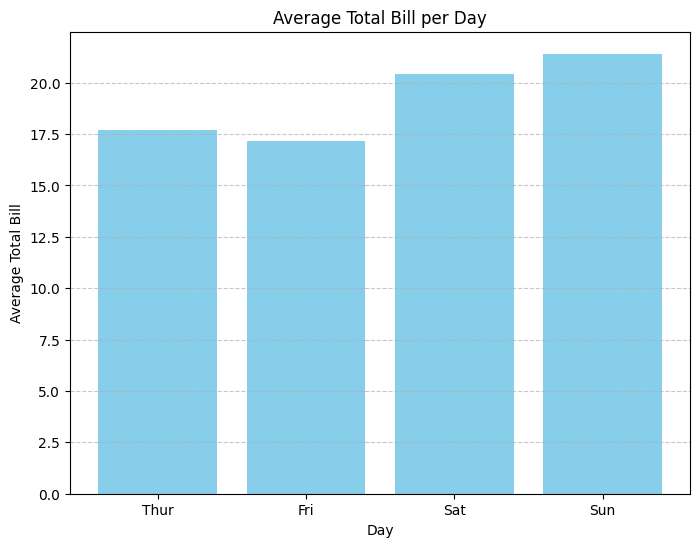

In [16]:
average_bill_per_day = tips.groupby('day')['total_bill'].mean().reindex(['Thur', 'Fri', 'Sat', 'Sun'])

plt.figure(figsize=(8, 6))
plt.bar(average_bill_per_day.index, average_bill_per_day.values, color='skyblue')
plt.title('Average Total Bill per Day')
plt.xlabel('Day')
plt.ylabel('Average Total Bill')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 9. Create a scatter plot with the day as the y-axis and tip as the x-axis, differ the dots by sex

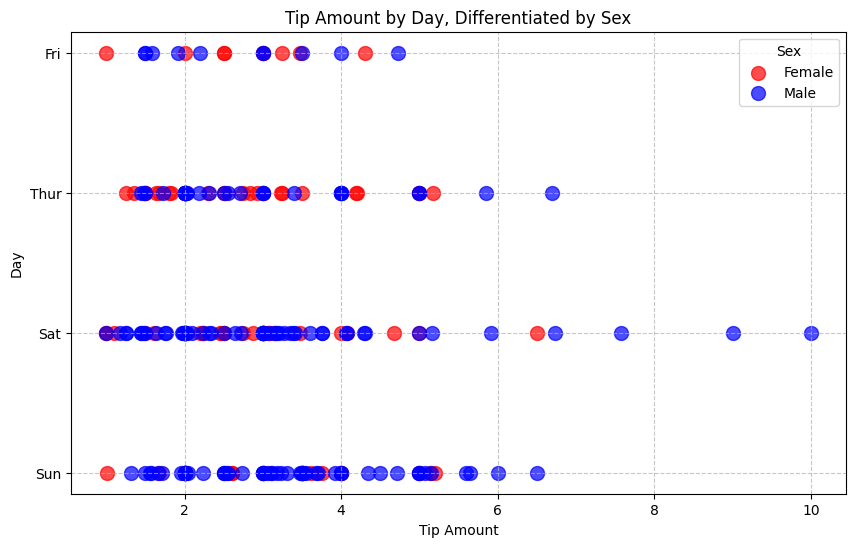

In [23]:
plt.figure(figsize=(10, 6))
sexes = tips['sex'].unique()
colors = {'Male': 'blue', 'Female': 'red'}

# Plot data for each sex
for sex in sexes:
    subset = tips[tips['sex'] == sex]
    plt.scatter(x=subset['tip'], y=subset['day'], color=colors[sex], label=sex, s=100, alpha=0.7)

plt.title('Tip Amount by Day, Differentiated by Sex')
plt.xlabel('Tip Amount')
plt.ylabel('Day')
plt.legend(title='Sex')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 10.  Create a box plot presenting the total_bill per day differetiation the time (Dinner or Lunch)

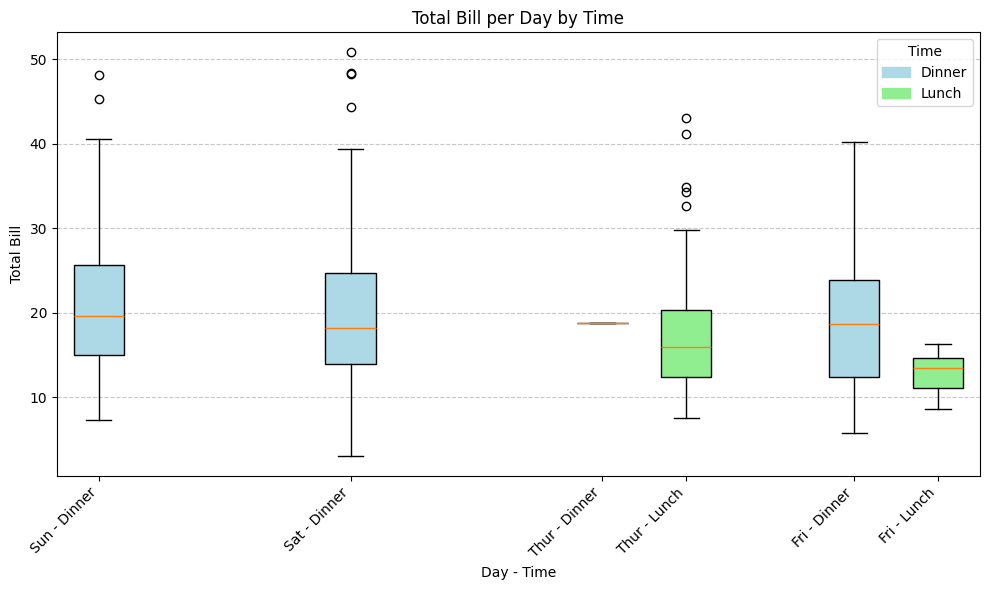

In [18]:
days = tips['day'].unique()
times = tips['time'].unique()

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for box plot
data_to_plot = []
labels = []
positions = []

for i, day in enumerate(days):
    day_data = []
    day_labels = []
    for time_idx, time_val in enumerate(times):
        subset = tips[(tips['day'] == day) & (tips['time'] == time_val)]
        if not subset.empty:
            day_data.append(subset['total_bill'])
            day_labels.append(f'{day} - {time_val}')
            positions.append(i * (len(times) + 1) + time_idx) # Calculate position to group by day

    # Combine data for the current day if both dinner and lunch exist
    if len(day_data) > 0:
        data_to_plot.extend(day_data)
        labels.extend(day_labels)


# Create the box plot
box_plot = ax.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.6)

# Customize colors for Dinner and Lunch if both are present
color_map = {'Dinner': 'lightblue', 'Lunch': 'lightgreen'}
current_data_idx = 0
for i, day in enumerate(days):
    for time_val in times:
        subset = tips[(tips['day'] == day) & (tips['time'] == time_val)]
        if not subset.empty:
            box = box_plot['boxes'][current_data_idx]
            box.set_facecolor(color_map.get(time_val, 'gray'))
            current_data_idx += 1


ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Total Bill per Day by Time')
ax.set_xlabel('Day - Time')
ax.set_ylabel('Total Bill')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend manually
handles = [plt.Rectangle((0,0),1,1, color=color_map[time_val]) for time_val in times if time_val in color_map]
labels_legend = [time_val for time_val in times if time_val in color_map]
ax.legend(handles, labels_legend, title='Time')

plt.tight_layout()
plt.show()

### Step 11. Create two histograms of the tip value based for Dinner and Lunch. They must be side by side.

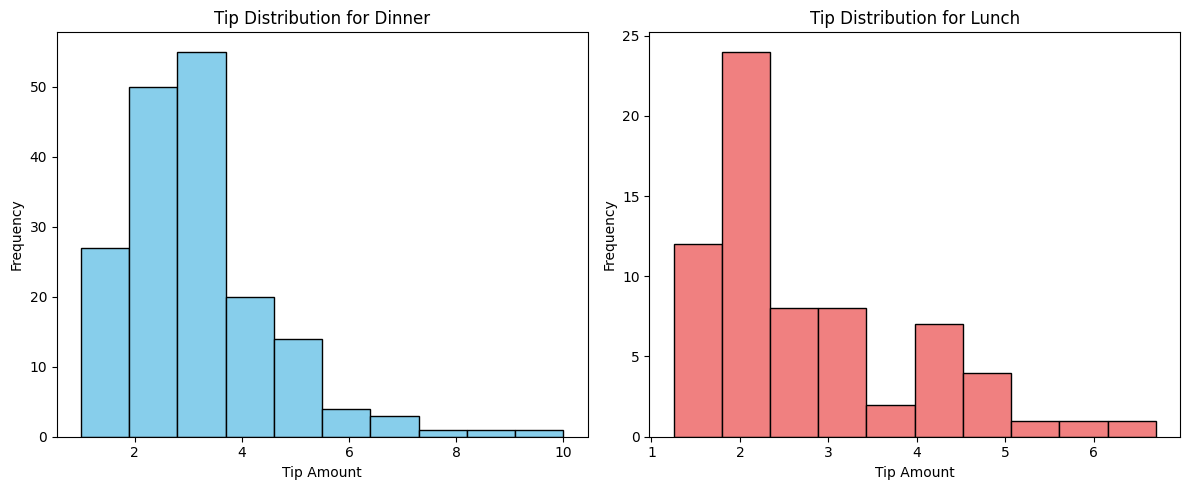

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Dinner tips
axes[0].hist(tips[tips['time'] == 'Dinner']['tip'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Tip Distribution for Dinner')
axes[0].set_xlabel('Tip Amount')
axes[0].set_ylabel('Frequency')

# Histogram for Lunch tips
axes[1].hist(tips[tips['time'] == 'Lunch']['tip'], bins=10, color='lightcoral', edgecolor='black')
axes[1].set_title('Tip Distribution for Lunch')
axes[1].set_xlabel('Tip Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Step 12. Create two scatterplots graphs, one for Male and another for Female, presenting the total_bill value and tip relationship, differing by smoker or no smoker
### They must be side by side.

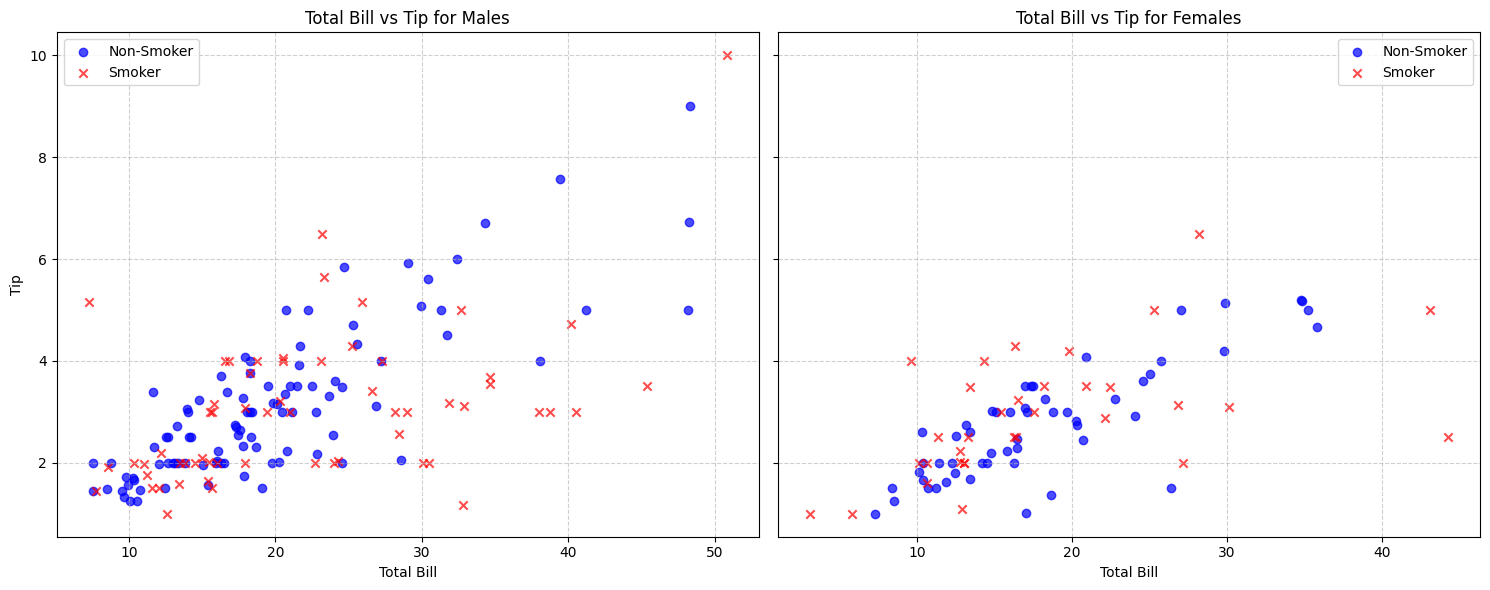

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Data for Male
male_tips = tips[tips['sex'] == 'Male']
male_smoker = male_tips[male_tips['smoker'] == 'Yes']
male_non_smoker = male_tips[male_tips['smoker'] == 'No']

# Plot for Male
axes[0].scatter(male_non_smoker['total_bill'], male_non_smoker['tip'], color='blue', label='Non-Smoker', alpha=0.7)
axes[0].scatter(male_smoker['total_bill'], male_smoker['tip'], color='red', label='Smoker', alpha=0.7, marker='x')
axes[0].set_title('Total Bill vs Tip for Males')
axes[0].set_xlabel('Total Bill')
axes[0].set_ylabel('Tip')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Data for Female
female_tips = tips[tips['sex'] == 'Female']
female_smoker = female_tips[female_tips['smoker'] == 'Yes']
female_non_smoker = female_tips[female_tips['smoker'] == 'No']

# Plot for Female
axes[1].scatter(female_non_smoker['total_bill'], female_non_smoker['tip'], color='blue', label='Non-Smoker', alpha=0.7)
axes[1].scatter(female_smoker['total_bill'], female_smoker['tip'], color='red', label='Smoker', alpha=0.7, marker='x')
axes[1].set_title('Total Bill vs Tip for Females')
axes[1].set_xlabel('Total Bill')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### BONUS: Create your own question and answer it using a graph.

Create a box plot of total bills grouped by day

/tmp/ipykernel_40590/2287907617.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=day_order, patch_artist=True, medianprops={'color': 'red'})


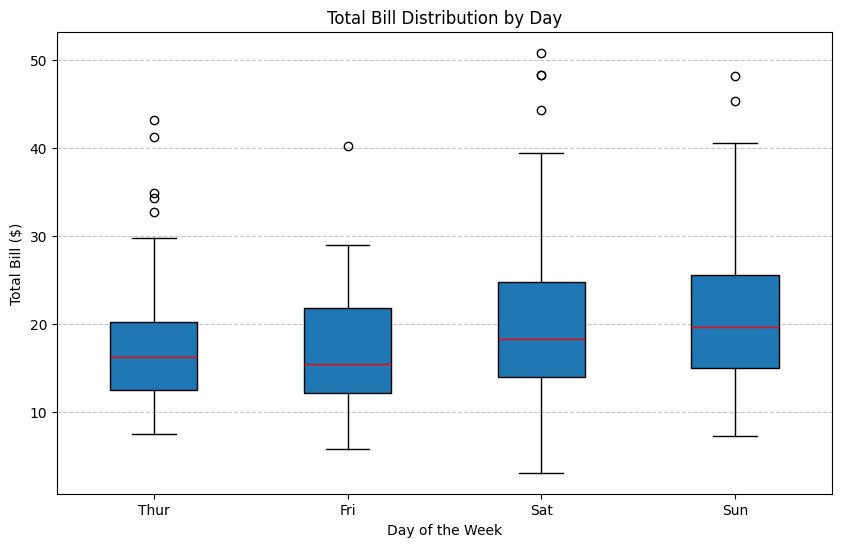

In [22]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
data_to_plot = [tips[tips['day'] == day]['total_bill'].values for day in day_order]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=day_order, patch_artist=True, medianprops={'color': 'red'})
plt.title('Total Bill Distribution by Day')
plt.xlabel('Day of the Week')
plt.ylabel('Total Bill ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()